# EDA and Preprocessing

## 1. Imports

In [70]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [71]:
df = pd.read_csv('../data/tehranhouses.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (3479, 7)


,Area,Room,Parking,Warehouse,Elevator,Address,Price(USD)
0,63,1,True,True,True,Shahran,61666.67
1,60,1,True,True,True,Shahran,61666.67
2,79,2,True,True,True,Pardis,18333.33
3,95,2,True,True,True,Shahrake Qods,30083.33
4,123,2,True,True,True,Shahrake Gharb,233333.33


In [72]:
# Drop Toman Price
if 'price' in df.columns:
    df = df.drop(columns=['price'])

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   object 
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   object 
 6   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(1), int64(1), object(2)
memory usage: 119.0+ KB


In [74]:
df.describe(include='all')

,Area,Room,Parking,Warehouse,Elevator,Address,Price(USD)
count,3479,3479.000000,3479,3479,3479,3456,3.479000e+03
unique,243,NaN,2,2,2,192,NaN
top,75,NaN,True,True,True,Punak,NaN
freq,111,NaN,2950,3182,2739,161,NaN
mean,NaN,2.079908,NaN,NaN,NaN,NaN,1.786341e+05
std,NaN,0.758275,NaN,NaN,NaN,NaN,2.699978e+05
min,NaN,0.000000,NaN,NaN,NaN,NaN,1.200000e+02
25%,NaN,2.000000,NaN,NaN,NaN,NaN,4.727500e+04
50%,NaN,2.000000,NaN,NaN,NaN,NaN,9.666667e+04
75%,NaN,2.000000,NaN,NaN,NaN,NaN,2.000000e+05


## 3. Data Cleaning

### 3.1 Fix Types

In [75]:
# Area stored as string
df['Area'] = pd.to_numeric(df['Area'].str.replace(',', ''), errors='coerce')

# Boolean amenity columns change to int(0/1)
bool_cols = ['Parking', 'Warehouse', 'Elevator']
df[bool_cols] = df[bool_cols].astype(int)

df.dtypes

Area            int64
Room            int64
Parking         int64
Warehouse       int64
Elevator        int64
Address        object
Price(USD)    float64
dtype: object

### 3.2 Drop Missing Values

In [76]:
print(f"Missing values before drop:\n{df.isnull().sum()}\n")
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Shape after drop: {df.shape}")

Missing values before drop:
Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price(USD)     0
dtype: int64

Shape after drop: (3456, 7)


## 4. Exploratory Data Analysis

### 4.1 Target Distributions

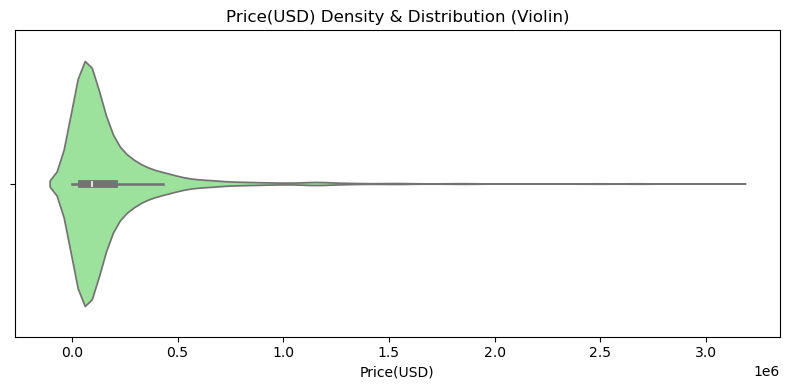

In [77]:
plt.figure(figsize=(8, 4))
sns.violinplot(data=df, x='Price(USD)', color='lightgreen')

plt.title('Price(USD) Density & Distribution (Violin)')
plt.tight_layout()
plt.show()

### 4.2 Correlation Heatmap

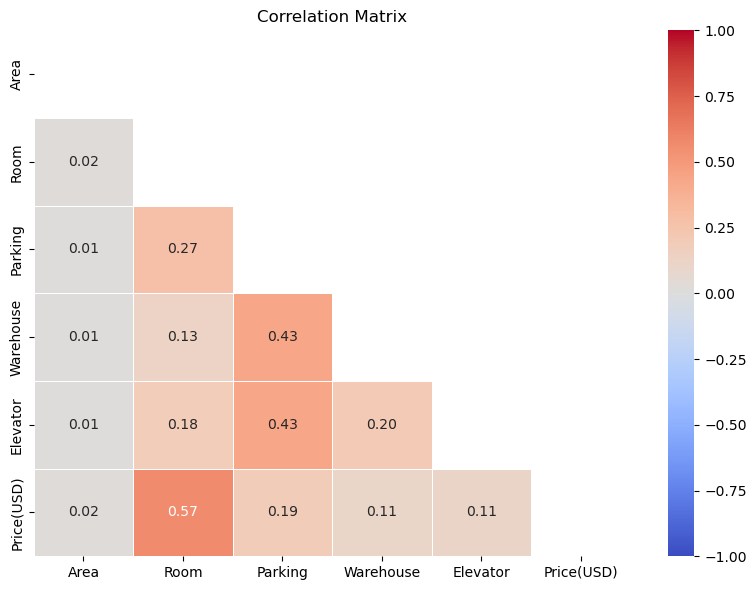

In [78]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### 4.3 Amenity Distributions (Parking / Warehouse / Elevator)

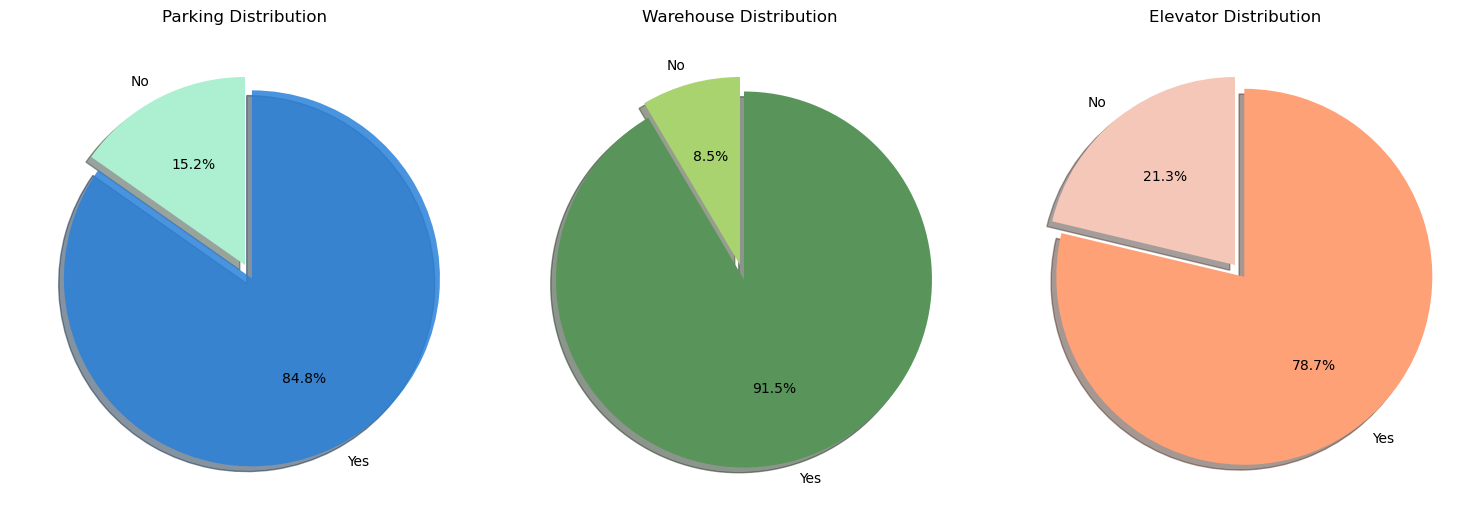

In [79]:
colors_list = [['#ADEFD1FF',"#2981DAD8"], ["#A9D36FFF","#59945A"], ['#F5C7B8FF','#FFA177FF']]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, colors in zip(axes, bool_cols, colors_list):
    counts = df[col].value_counts().sort_index()
    ax.pie(counts, labels=['No','Yes'], colors=colors,
           autopct='%1.1f%%', startangle=90, shadow=True, explode=[0, 0.08])
    ax.set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

## 5. Outlier Detection & Removal

### 5.1 Feature Skewness & Boxplots

Skewness:
 Area          43.827765
Price(USD)     4.765172
Room           0.623938
Elevator      -1.404947
Parking       -1.934179
Warehouse     -2.975864
dtype: float64


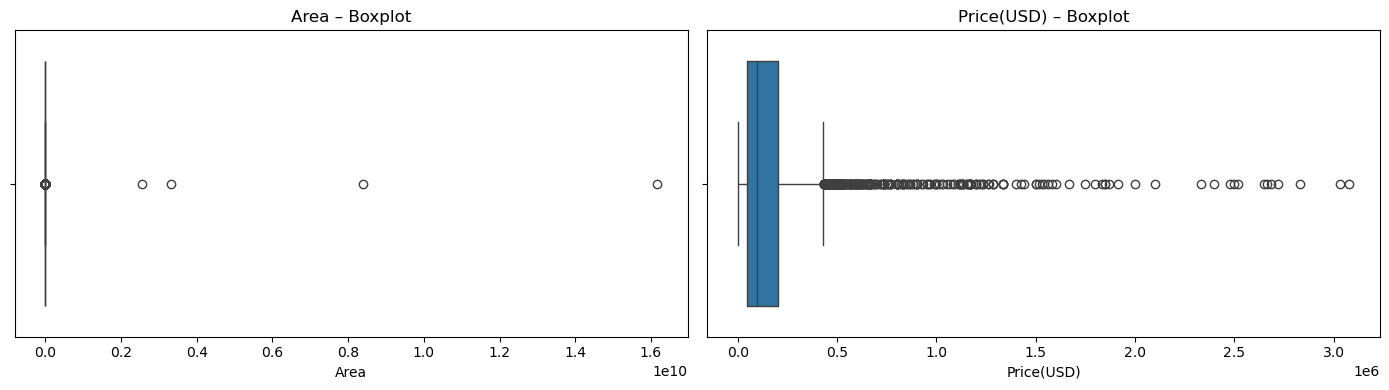

In [80]:
print("Skewness:\n", df.skew(numeric_only=True).sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['Area', 'Price(USD)']):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f'{col} – Boxplot')
plt.tight_layout()
plt.show()

### 5.2 IQR Bounds (reference)

In [81]:
def iqr_bounds(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for col in ['Area', 'Price(USD)']:
    lo, hi = iqr_bounds(df[col])
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col}: lower={lo:,.1f}  upper={hi:,.1f}  outliers={n_out}")

Area: lower=-9.0  upper=199.0  outliers=237
Price(USD): lower=-181,666.7  upper=429,000.0  outliers=310


### 5.3 Domain-Knowledge Thresholds & Filter

In [82]:
BOUNDS = {
    'Area':       (20, 1000),
    'Price(USD)': (1_000, 10_000_000),
    'Room':       (0, 6),
}

# Create the valid data mask
mask = pd.concat(
    [df[col].between(lo, hi) for col, (lo, hi) in BOUNDS.items()], axis=1
).all(axis=1)

# Create a dataframe of ONLY the dropped rows
dropped_df = df[~mask]

print(f"Rows removed: {dropped_df.shape[0]}  |  {df.shape[0]} → {mask.sum()}")
print("\nSamples of Dropped Data:")

# Display the dropped rows 
if not dropped_df.empty:
    print(dropped_df[['Area', 'Price(USD)', 'Room']].head(20)) # Shows the first 20 dropped rows
else:
    print("No rows were dropped.")

# Finally, apply the filter to df
df = df[mask].reset_index(drop=True)
df.shape

Rows removed: 6  |  3456 → 3450

Samples of Dropped Data:
             Area  Price(USD)  Room
135           160      120.00     1
569    3310000000   110333.33     2
706   16160000000   538666.67     3
1598   8400000000   290000.00     2
2161         3600   324000.00     2
2788   2550000000    85000.00     2


(3450, 7)

### 5.4 Distributions After Cleaning

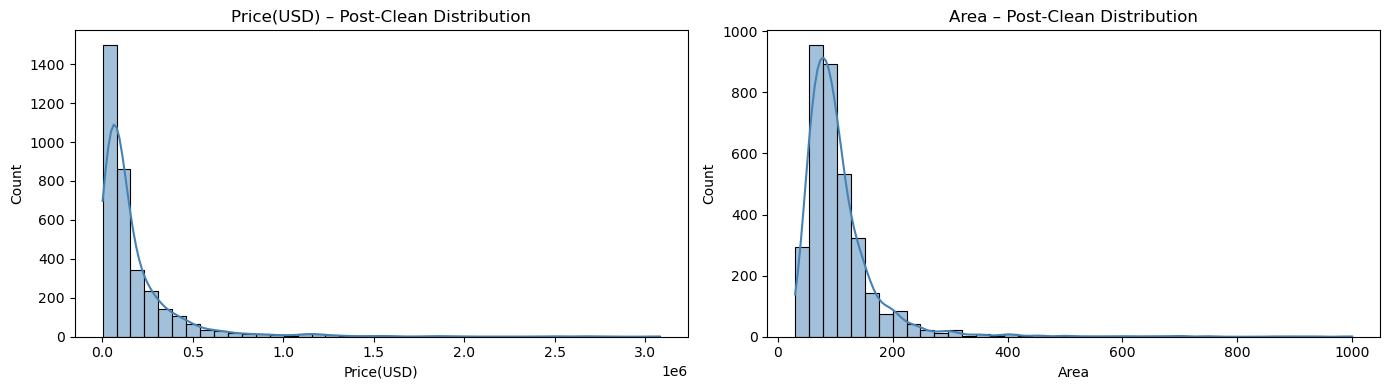

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ['Price(USD)', 'Area']):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'{col} – Post-Clean Distribution')
plt.tight_layout()
plt.show()

### 5.5 Price vs. Area (by Room Count)

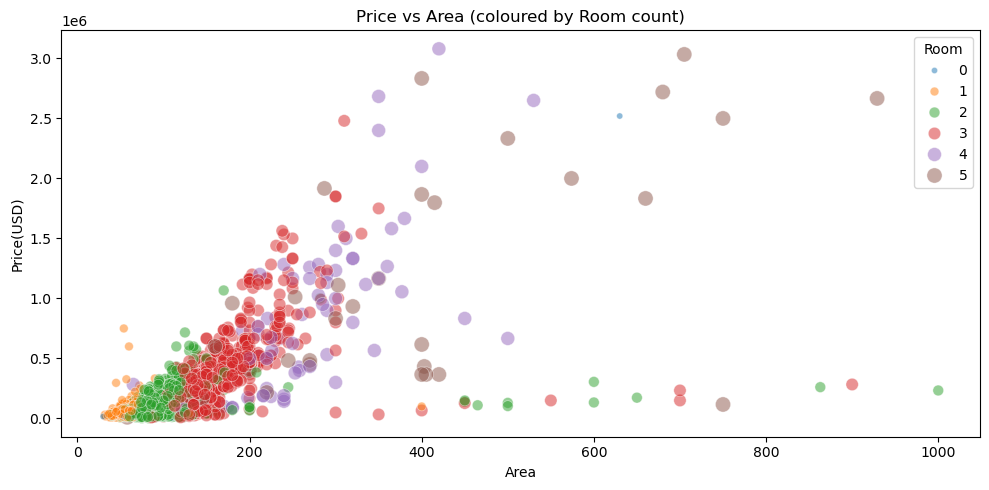

In [84]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Area', y='Price(USD)',
                hue='Room', palette='tab10', alpha=0.5,
                size='Room', sizes=(20, 120))
plt.title('Price vs Area (coloured by Room count)')
plt.tight_layout()
plt.show()

## 6. Feature Engineering

### 6.1 One-Hot Encode Address

In [85]:
df_final = pd.get_dummies(df, columns=['Address'], drop_first=True)
print(f"Shape after encoding: {df_final.shape}")
df_final.head()

Shape after encoding: (3450, 197)


,Area,Room,Parking,Warehouse,Elevator,Price(USD),Address_Abbasabad,Address_Absard,Address_Abuzar,Address_Afsarieh,...,Address_Waterfall,Address_West Ferdows Boulevard,Address_West Pars,Address_Yaftabad,Address_Yakhchiabad,Address_Yousef Abad,Address_Zafar,Address_Zaferanieh,Address_Zargandeh,Address_Zibadasht
0,63,1,1,1,1,61666.67,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,60,1,1,1,1,61666.67,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,79,2,1,1,1,18333.33,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,95,2,1,1,1,30083.33,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,123,2,1,1,1,233333.33,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 7. Save Processed Data

In [86]:
# Save as Parquet
parquet_path = os.path.join(output_dir, 'tehranhouses_preprocessed.parquet')
df_final.to_parquet(parquet_path, index=False)